<a href="https://colab.research.google.com/github/olawaleaboderin/machine_learning/blob/main/winequality_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT REQUIRED LIBRARIES

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Building and training the model
import torch
from torch import nn

# Preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

LOAD THE DATASET

In [3]:
# Load the white wine quality dataset from my GitHub account
data = pd.read_csv(
    "https://raw.githubusercontent.com/olawaleaboderin/machine_learning/main/Assignment1/winequality-white.csv",
    sep=";"
)

# Display the first few rows to confirm the data loaded correctly
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


DATA PREPARATION

In [4]:
from torch.utils.data import DataLoader, TensorDataset

# Separate input features (X) and target variable (y)
X = data.drop('quality', axis=1)
y = data['quality']

# Split the dataset into training and testing sets 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler to normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

# Convert NumPy arrays to PyTorch tensors for model training
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
# Reshape the target values to column vectors
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# Combine features and labels into TensorDataset objects
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define the number of training epochs
num_epochs = 200

print("Data preparation complete. X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, train_loader, and test_loader are created.")

Data preparation complete. X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, train_loader, and test_loader are created.


DEFINE THE LINEAR REGRESSION MODEL

In [5]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

# Instantiate the model
input_dim = X_train_tensor.shape[1]  # Number of features
output_dim = y_train_tensor.shape[1] # Number of target variables (1 in this case)
model = LinearRegressionModel(input_dim, output_dim)

print(f"Input Dimension: {input_dim}")
print(f"Output Dimension: {output_dim}")
print("Model architecture:")
print(model)

Input Dimension: 11
Output Dimension: 1
Model architecture:
LinearRegressionModel(
  (linear): Linear(in_features=11, out_features=1, bias=True)
)


DEFINE LOSS FUNCTION AND OPTIMIZER

In [6]:
import torch.optim as optim

# Initialize the Mean Squared Error (MSE) loss function
criterion = nn.MSELoss()

# Initialize an optimizer to update the model parameters during training
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Create an empty list to store training losses
train_losses = []

print("Loss function (criterion), optimizer, num_epochs, and train_losses initialized.")

Loss function (criterion), optimizer, num_epochs, and train_losses initialized.


TRAIN THE MODEL

In [7]:
all_predictions = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    current_epoch_losses = []

    for X_batch, y_batch in train_loader:
        # Zero out the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        # Calculate the loss
        loss = criterion(outputs, y_batch)

        # Backward pass
        loss.backward()

        # Update model parameters
        optimizer.step()
        current_epoch_losses.append(loss.item())

    # Calculate average training loss for the epoch
    avg_epoch_loss = np.mean(current_epoch_losses)
    train_losses.append(avg_epoch_loss)

    # Periodically store predictions for animation
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == num_epochs - 1:
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad(): # Disable gradient calculation for inference
            predictions = model(X_test_tensor).detach().numpy()
            all_predictions.append(predictions)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}, Stored predictions for animation.')
    else:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')

print("Training complete and predictions have been stored for animation.")

Epoch [1/200], Loss: 32.7701, Stored predictions for animation.
Epoch [2/200], Loss: 26.2262
Epoch [3/200], Loss: 20.8378
Epoch [4/200], Loss: 16.4259
Epoch [5/200], Loss: 12.7249
Epoch [6/200], Loss: 9.7368
Epoch [7/200], Loss: 7.3740
Epoch [8/200], Loss: 5.5504
Epoch [9/200], Loss: 4.1426
Epoch [10/200], Loss: 3.0813, Stored predictions for animation.
Epoch [11/200], Loss: 2.3007
Epoch [12/200], Loss: 1.7411
Epoch [13/200], Loss: 1.3320
Epoch [14/200], Loss: 1.0598
Epoch [15/200], Loss: 0.8738
Epoch [16/200], Loss: 0.7612
Epoch [17/200], Loss: 0.6753
Epoch [18/200], Loss: 0.6302
Epoch [19/200], Loss: 0.6019
Epoch [20/200], Loss: 0.5901, Stored predictions for animation.
Epoch [21/200], Loss: 0.5734
Epoch [22/200], Loss: 0.5726
Epoch [23/200], Loss: 0.5652
Epoch [24/200], Loss: 0.5722
Epoch [25/200], Loss: 0.5690
Epoch [26/200], Loss: 0.5640
Epoch [27/200], Loss: 0.5652
Epoch [28/200], Loss: 0.5655
Epoch [29/200], Loss: 0.5664
Epoch [30/200], Loss: 0.5674, Stored predictions for anima

VISUALIZE TRAINING LOSS

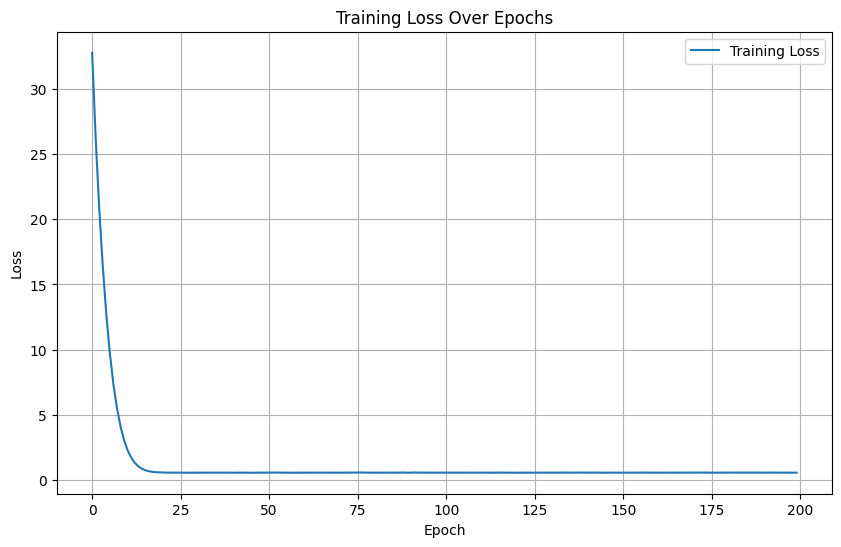

Training loss plot generated.


In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()
print("Training loss plot generated.")

EVALUATE MODEL PERFORMANCE

In [9]:
from sklearn.metrics import mean_squared_error

# Set the model to evaluation mode
model.eval()

# Disable gradient calculations
with torch.no_grad():
    # Make predictions on the X_test_tensor
    y_pred_tensor = model(X_test_tensor)

    # Convert predictions and y_test_tensor to NumPy arrays
    y_test_np = y_test_tensor.numpy()
    y_pred_np = y_pred_tensor.numpy()

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test_np, y_pred_np)

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Print the calculated MSE and RMSE values
print(f"Mean Squared Error (MSE) on test set: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) on test set: {rmse:.4f}")

Mean Squared Error (MSE) on test set: 0.5674
Root Mean Squared Error (RMSE) on test set: 0.7533


ACTUAL VS PREDICTED VISUALIZATION

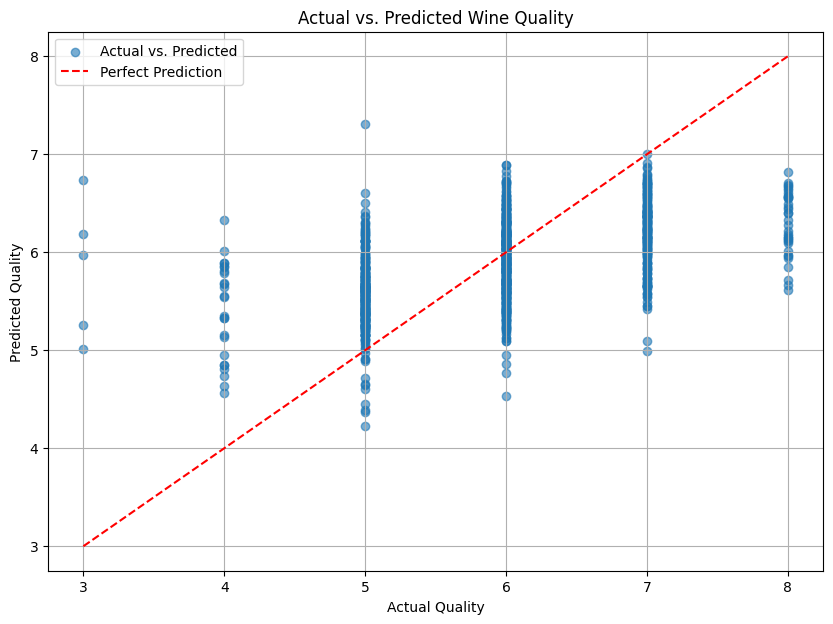

Actual vs Predicted plot generated.


In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test_np, y_pred_np, alpha=0.6, label='Actual vs. Predicted')

# Add a diagonal line for perfect predictions
min_val = min(y_test_np.min(), y_pred_np.min())
max_val = max(y_test_np.max(), y_pred_np.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Actual vs. Predicted Wine Quality')
plt.legend()
plt.grid(True)
plt.show()
print("Actual vs Predicted plot generated.")

ANIMATION OF MODEL LEARNING OVER EPOCHS

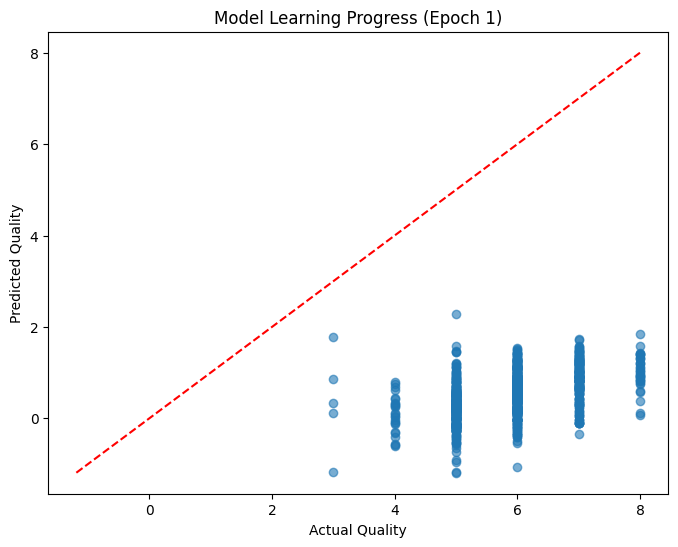

In [11]:
from IPython.display import HTML
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8,6))

# Create labels for which epoch each stored prediction corresponds to
stored_epochs = [1]
for i in range(1, num_epochs):
    if (i+1) % 10 == 0 or i == num_epochs-1:
        stored_epochs.append(i+1)

def update(frame):

    ax.clear()

    preds = all_predictions[frame].flatten()

    ax.scatter(y_test_np, preds, alpha=0.6)

    # Perfect prediction line
    min_val = min(y_test_np.min(), preds.min())
    max_val = max(y_test_np.max(), preds.max())

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")

    ax.set_title(f"Model Learning Progress (Epoch {stored_epochs[frame]})")

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(all_predictions),
    interval=600
)

HTML(ani.to_jshtml())